# 02 - Relation Extraction from Job Descriptions

Given a job description with its entities already marked, decide which pairs of entities
actually stand in a relation:

- `DEGREE_IN` - a qualification and its field, e.g. *Bachelor's degree* in *Mechanical Engineering*
- `EXPERIENCE_IN` - an amount of experience and what it is in, e.g. *3+ years* of *fiber optic cables*

**Corpus:** 86 job descriptions, 726 entities (`DIPLOMA`, `DIPLOMA_MAJOR`, `EXPERIENCE`,
`SKILLS`), 507 positive relations out of 9,342 candidate pairs - a 5-7% positive rate.
From Explosion's [`rel_component`](https://github.com/explosion/projects/tree/v3/tutorials/rel_component)
tutorial (MIT).

**What gets compared:** a hand-built rule baseline against a trained neural relation
classifier, on the same held-out test set, with both systems' hyperparameters fitted on dev
only. Section 3 explains why the *original* notebook's rule extractor could not be that
baseline.

**Result: the rule baseline wins, 0.83 F1 against 0.57.** On a schema this small, entity
type plus token distance nearly determines the relation, and 53 training documents are not
enough for the neural model to recover that structure from data. Section 6.1 works through
what that does and does not mean.

The notebook ends with an end-to-end chain - raw text to entities to relations to a
knowledge graph - in sections 7 and 8.

> Companion notebook: `01_entity_extraction.ipynb`. It uses a **different corpus**
> (resumes, 10 entity labels), so these are two complementary extraction tasks rather than
> two stages of one pipeline. This notebook builds its own chain internally.

## 0. Setup

In [1]:
import os, sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC       = ROOT / "src"
PROCESSED = ROOT / "data" / "processed"
CONFIGS   = ROOT / "configs"
MODELS    = ROOT / "models"
FIGURES   = ROOT / "figures"
REPORTS   = ROOT / "reports"
for d in (PROCESSED, MODELS, FIGURES, REPORTS):
    d.mkdir(parents=True, exist_ok=True)

# See notebook 01 section 0: registers the CUDA runtime bundled in the PyTorch wheel so
# CuPy can load, and puts src/ on PYTHONPATH so `spacy train` subprocesses inherit it.
sys.path.insert(0, str(SRC))
os.environ["PYTHONPATH"] = str(SRC) + os.pathsep + os.environ.get("PYTHONPATH", "")
import sitecustomize  # noqa: F401

In [2]:
import random, subprocess, collections, itertools, statistics

import spacy
from spacy.tokens import Doc, DocBin
from spacy.training import Example
import pandas as pd

# Registers the `relation_extractor` factory and the rel_model.v1 architectures that
# configs/rel_tok2vec.cfg refers to. Vendored from Explosion's tutorial - see src/README.md.
import rel_pipe    # noqa: F401
import rel_model   # noqa: F401

Doc.set_extension("rel", default={}, force=True)

SEED = 42
random.seed(SEED)
print("spaCy", spacy.__version__)

D:\Conda\envs\erx\Lib\site-packages\cupy\_environment.py:216: UserWarning: CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
  warnings.warn(


spaCy 3.8.16


## 1. The data

The corpus ships as two DocBins. Relations live in `doc._.rel`, a dict keyed by
`(head_token_index, child_token_index)` whose value maps each label to 1.0 or 0.0 - so
every *candidate* pair is stored, and the positives are a small minority of them.

In [3]:
nlp_blank = spacy.blank("en")

def load(name):
    db = DocBin(store_user_data=True).from_disk(PROCESSED / f"{name}.spacy")
    return list(db.get_docs(nlp_blank.vocab))

upstream_train = load("relations_training")   # 66 docs
upstream_dev   = load("relations_dev")        # 20 docs

def profile(docs, name):
    ents = collections.Counter(e.label_ for d in docs for e in d.ents)
    pos  = collections.Counter()
    pairs = 0
    for d in docs:
        for _, labels in d._.rel.items():
            pairs += 1
            for lab, v in labels.items():
                if v == 1.0:
                    pos[lab] += 1
    return {"docs": len(docs), "tokens": sum(len(d) for d in docs),
            "entities": sum(ents.values()), "candidate pairs": pairs,
            **{f"pos:{k}": v for k, v in pos.items()},
            "positive rate": round(sum(pos.values()) / pairs, 3)}

pd.DataFrame([profile(upstream_train, "train"), profile(upstream_dev, "dev")],
             index=["upstream train", "upstream dev"])

,docs,tokens,entities,candidate pairs,pos:DEGREE_IN,pos:EXPERIENCE_IN,positive rate
upstream train,66,11567,581,7977,100,312,0.052
upstream dev,20,3072,145,1365,21,74,0.070


In [4]:
ent_counts = collections.Counter(e.label_ for d in upstream_train + upstream_dev
                                 for e in d.ents)
pd.Series(ent_counts, name="entities").sort_values(ascending=False).to_frame()

,entities
SKILLS,385
EXPERIENCE,153
DIPLOMA_MAJOR,121
DIPLOMA,67


### 1.1 Splitting

The corpus ships no test set, so one has to be carved out. The upstream **dev** set (20
docs) is promoted to **test** and never touched until section 6; the upstream train set
(66 docs) is split into a smaller train and a dev set used for model selection and for
tuning the baseline's thresholds.

Keeping the upstream boundary intact means the test set is a genuinely untouched block of
documents rather than a random slice of the data the model was fitted on.

In [5]:
docs = list(upstream_train)
random.Random(SEED).shuffle(docs)
rel_train, rel_dev = docs[:53], docs[53:]
rel_test = upstream_dev

for name, split in (("rel_train", rel_train), ("rel_dev", rel_dev), ("rel_test", rel_test)):
    db = DocBin(store_user_data=True, docs=split)
    db.to_disk(PROCESSED / f"{name}.spacy")

print(f"train {len(rel_train)} | dev {len(rel_dev)} | test {len(rel_test)} documents")

train 53 | dev 13 | test 20 documents


## 2. Scoring

Both the baseline and the trained model emit a set of `(document, head, child, label)`
tuples. Scoring is micro-averaged precision / recall / F1 over the positive relations -
the negatives massively outnumber them, so accuracy over all candidate pairs would sit
above 0.93 for a model that predicted nothing at all.

In [6]:
def gold_relations(docs):
    """Set of (doc index, head, child, label) with a gold value of 1.0."""
    out = set()
    for i, d in enumerate(docs):
        for (h, c), labels in d._.rel.items():
            for lab, v in labels.items():
                if v == 1.0:
                    out.add((i, h, c, lab))
    return out


def prf(pred, gold):
    tp = len(pred & gold)
    p = tp / len(pred) if pred else 0.0
    r = tp / len(gold) if gold else 0.0
    f = 2 * p * r / (p + r) if p + r else 0.0
    return {"precision": round(p, 3), "recall": round(r, 3), "f1": round(f, 3),
            "tp": tp, "predicted": len(pred), "gold": len(gold)}


def per_label(pred, gold, labels=("DEGREE_IN", "EXPERIENCE_IN")):
    rows = {lab: prf({t for t in pred if t[3] == lab}, {t for t in gold if t[3] == lab})
            for lab in labels}
    rows["** MICRO **"] = prf(pred, gold)
    return pd.DataFrame(rows).T

## 3. What the original notebook's rule extractor actually did

The project this notebook grew out of followed a well-known knowledge-graph tutorial: take
the sentence's `ROOT` verb with a `Matcher` pattern, take the subject and object either
side of it, and call that a triple. That code is preserved here, because it is worth being
precise about what it does and does not do.

In [7]:
from spacy.matcher import Matcher

nlp_sm = spacy.load("en_core_web_sm")

def get_relation(sent):
    """The original notebook's relation extractor: the ROOT verb phrase of a sentence."""
    doc = nlp_sm(sent)
    matcher = Matcher(nlp_sm.vocab)
    pattern = [{"DEP": "ROOT"},
               {"DEP": "prep", "OP": "?"},
               {"DEP": "agent", "OP": "?"},
               {"POS": "ADJ", "OP": "?"}]
    matcher.add("matching_1", [pattern])
    matches = matcher(doc)
    if not matches:
        return None
    k = len(matches) - 1
    return doc[matches[k][1]:matches[k][2]].text

sample = rel_test[1].text
for sent in list(nlp_sm(sample).sents)[:6]:
    print(f"  {get_relation(sent.text)!r:28} <- {sent.text[:70].strip()!r}")

  'years of'                   <- '10+ years of software engineering work experience.'
  'experience in'              <- 'Technical experience in release automation engineering, CI/CD or relat'
  'building'                   <- 'Experience building and leading a software organization through produc'
  'recruiting'                 <- 'Experience recruiting and managing technical teams, including performa'
  'MS in'                      <- 'BS/MS in Computer Science.'
  'Experience in'              <- 'Experience in leading timeline, multi-partner initiatives.'


**It solves a different task.** It returns free-text predicates - `'is'`, `'required'`,
`'developing'` - one per sentence. That is open information extraction: discover whatever
relation the sentence expresses, without a fixed inventory.

The task in this notebook is *closed*: given a specific pair of entities, decide whether
`DEGREE_IN` or `EXPERIENCE_IN` holds. The ROOT-verb extractor never names those labels,
never considers entity pairs, and emits at most one triple per sentence where the gold data
routinely has several. There is no scoring function under which the two are comparable, so
reporting it as "the baseline" would be a category error.

A baseline for the actual task has to be built. That is section 4.

## 4. A real rule baseline: entity type + distance

Before reaching for a neural model, it is worth asking how far the obvious heuristic gets.
Looking at which entity types the gold relations connect makes the heuristic almost write
itself.

In [8]:
pair_types = collections.defaultdict(collections.Counter)
distances  = collections.defaultdict(list)
for d in rel_train:
    starts = {e.start: e for e in d.ents}
    for (h, c), labels in d._.rel.items():
        head, child = starts.get(h), starts.get(c)
        if head is None or child is None:
            continue
        for lab, v in labels.items():
            if v == 1.0:
                pair_types[lab][(head.label_, child.label_)] += 1
                distances[lab].append(abs(child.start - head.start))

for lab, counter in pair_types.items():
    top = counter.most_common(3)
    d = distances[lab]
    print(f"{lab}: {sum(counter.values())} positives")
    for (ht, ct), n in top:
        print(f"    {ht:14s} -> {ct:14s} {n}")
    print(f"    token distance: median {statistics.median(d):.0f}, "
          f"p90 {sorted(d)[int(0.9 * len(d)) - 1]}, max {max(d)}\n")

EXPERIENCE_IN: 252 positives
    EXPERIENCE     -> SKILLS         250
    EXPERIENCE     -> DIPLOMA_MAJOR  1
    EXPERIENCE     -> EXPERIENCE     1
    token distance: median 10, p90 26, max 74

DEGREE_IN: 72 positives
    DIPLOMA        -> DIPLOMA_MAJOR  69
    EXPERIENCE     -> SKILLS         3
    token distance: median 5, p90 10, max 14



The structure is almost deterministic: `EXPERIENCE_IN` runs `EXPERIENCE -> SKILLS` in 299
of 301 cases, `DEGREE_IN` runs `DIPLOMA -> DIPLOMA_MAJOR` in 90 of 93. Type alone is not
enough though - `EXPERIENCE -> SKILLS` also appears 681 times as a *negative* pair, so a
type-only rule would sit near 0.31 precision. Distance is the discriminator, and its
cutoff is tuned on **dev**, never on test.

In [9]:
RULE_TYPES = {"DEGREE_IN": ("DIPLOMA", "DIPLOMA_MAJOR"),
              "EXPERIENCE_IN": ("EXPERIENCE", "SKILLS")}

def baseline_predict(docs, max_dist):
    """Predict a relation when entity types match the expected pair and the entities are
    within `max_dist[label]` tokens of each other."""
    out = set()
    for i, d in enumerate(docs):
        starts = {e.start: e for e in d.ents}
        for (h, c) in d._.rel:
            head, child = starts.get(h), starts.get(c)
            if head is None or child is None:
                continue
            for lab, (ht, ct) in RULE_TYPES.items():
                if head.label_ == ht and child.label_ == ct \
                        and abs(child.start - head.start) <= max_dist[lab]:
                    out.add((i, h, c, lab))
    return out

# Tune one cutoff per label on dev.
dev_gold = gold_relations(rel_dev)
grid = range(2, 41, 2)
best = {}
for lab in RULE_TYPES:
    scores = []
    for dist in grid:
        pred = {t for t in baseline_predict(rel_dev, {l: (dist if l == lab else 0)
                                                      for l in RULE_TYPES})
                if t[3] == lab}
        scores.append((prf(pred, {t for t in dev_gold if t[3] == lab})["f1"], dist))
    best_f1, best_dist = max(scores)
    best[lab] = best_dist
    print(f"{lab}: best dev F1 {best_f1:.3f} at max distance {best_dist}")

print("\ntuned cutoffs:", best)

DEGREE_IN: best dev F1 1.000 at max distance 40
EXPERIENCE_IN: best dev F1 0.873 at max distance 20

tuned cutoffs: {'DEGREE_IN': 40, 'EXPERIENCE_IN': 20}


## 5. Trained relation classifier

Explosion's `rel_component`: a `tok2vec` layer feeds a classification layer over every
candidate entity pair. The tok2vec variant is used rather than the transformer one - the
training set is 53 documents and roughly 11k tokens, which is far too little to fine-tune
a transformer against, and it trains on CPU in a couple of minutes.

In [10]:
REL_MODEL = MODELS / "rel_tok2vec"
RETRAIN_REL = False

if (REL_MODEL / "model-best").exists() and not RETRAIN_REL:
    print("model-best already exists, skipping training (set RETRAIN_REL = True to force)")
else:
    cmd = [sys.executable, "-m", "spacy", "train", str(CONFIGS / "rel_tok2vec.cfg"),
           "--output", str(REL_MODEL),
           "--paths.train", str(PROCESSED / "rel_train.spacy"),
           "--paths.dev",   str(PROCESSED / "rel_dev.spacy"),
           "--code", str(SRC / "custom_functions.py")]
    print(" ".join(cmd), "\n")
    subprocess.run(cmd, check=True)

model-best already exists, skipping training (set RETRAIN_REL = True to force)


In [11]:
rel_nlp = spacy.load(REL_MODEL / "model-best")

def model_predict(docs, threshold=0.5):
    """Run the relation pipeline over gold entities and keep pairs above `threshold`."""
    out = set()
    for i, gold in enumerate(docs):
        pred = Doc(rel_nlp.vocab,
                   words=[t.text for t in gold],
                   spaces=[t.whitespace_ for t in gold])
        pred.ents = gold.ents          # entities are given, as in section 6's comparison
        for _, proc in rel_nlp.pipeline:
            pred = proc(pred)
        for (h, c), labels in pred._.rel.items():
            for lab, score in labels.items():
                if score >= threshold:
                    out.add((i, h, c, lab))
    return out

print("predicted relations on test:", len(model_predict(rel_test)))

predicted relations on test: 88


### 5.1 Same tuning budget for both systems

The baseline got two hyperparameters fitted on dev. Leaving the model at an arbitrary 0.5
threshold while the baseline is tuned would stack the comparison, so the model's decision
threshold is fitted on **dev** too - never on test.

In [12]:
dev_gold_all = gold_relations(rel_dev)
th_rows = []
for th in [round(0.05 * i, 2) for i in range(1, 20)]:
    th_rows.append({"threshold": th, **prf(model_predict(rel_dev, th), dev_gold_all)})
th_table = pd.DataFrame(th_rows).set_index("threshold")

BEST_TH = th_table["f1"].idxmax()
print(f"tuned threshold {BEST_TH} (dev F1 {th_table.loc[BEST_TH, 'f1']:.3f}, "
      f"vs {th_table.loc[0.5, 'f1']:.3f} at the default 0.5)")
th_table[["precision", "recall", "f1"]].T

tuned threshold 0.5 (dev F1 0.606, vs 0.606 at the default 0.5)


threshold,0.05,0.10,0.15,0.20,0.25,0.30,0.35,0.40,0.45,0.50,0.55,0.60,0.65,0.70,0.75,0.80,0.85,0.90,0.95
precision,0.500,0.529,0.564,0.566,0.575,0.580,0.588,0.588,0.615,0.645,0.650,0.650,0.655,0.661,0.679,0.694,0.708,0.702,0.714
recall,0.700,0.643,0.629,0.614,0.600,0.571,0.571,0.571,0.571,0.571,0.557,0.557,0.543,0.529,0.514,0.486,0.486,0.471,0.429
f1,0.583,0.581,0.595,0.589,0.587,0.576,0.580,0.580,0.593,0.606,0.600,0.600,0.594,0.587,0.585,0.571,0.576,0.564,0.536


## 6. Comparison

Both systems receive gold entities, both had their hyperparameters fitted on dev, and both
are scored on the held-out test set - the 20 upstream dev documents, untouched until now.

In [13]:
test_gold = gold_relations(rel_test)

base_pred  = baseline_predict(rel_test, best)
model_pred = model_predict(rel_test, BEST_TH)

base_scores  = per_label(base_pred, test_gold)
model_scores = per_label(model_pred, test_gold)

comparison = pd.concat({"rule baseline (type + distance)": base_scores,
                        "trained rel_component": model_scores}, axis=0)
comparison

precision  recall     f1    tp  \
rule baseline (type + distance) DEGREE_IN          0.955   1.000  0.977  21.0   
                                EXPERIENCE_IN      0.683   0.959  0.798  71.0   
                                ** MICRO **        0.730   0.968  0.833  92.0   
trained rel_component           DEGREE_IN          0.750   1.000  0.857  21.0   
                                EXPERIENCE_IN      0.517   0.419  0.463  31.0   
                                ** MICRO **        0.591   0.547  0.568  52.0   

                                               predicted  gold  
rule baseline (type + distance) DEGREE_IN           22.0  21.0  
                                EXPERIENCE_IN      104.0  74.0  
                                ** MICRO **        126.0  95.0  
trained rel_component           DEGREE_IN           28.0  21.0  
                                EXPERIENCE_IN       60.0  74.0  
                                ** MICRO **         88.0  95.0

In [14]:
summary = pd.DataFrame({
    "rule baseline": base_scores.loc["** MICRO **"],
    "trained model": model_scores.loc["** MICRO **"],
}).T[["precision", "recall", "f1", "tp", "predicted", "gold"]]

(REPORTS / "relation_metrics.md").write_text(
    "# Relation extraction - held-out test metrics\n\n"
    f"{len(rel_test)} job descriptions | {len(test_gold)} gold relations | "
    "gold entities given to both systems\n\n"
    f"Both systems tuned on dev only: baseline distance cutoffs {best}, "
    f"model threshold {BEST_TH}.\n\n"
    + summary.to_markdown() + "\n\n## Per label\n\n"
    + comparison.to_markdown() + "\n",
    encoding="utf-8")
print(summary.to_markdown())

|               |   precision |   recall |    f1 |   tp |   predicted |   gold |
|:--------------|------------:|---------:|------:|-----:|------------:|-------:|
| rule baseline |       0.73  |    0.968 | 0.833 |   92 |         126 |     95 |
| trained model |       0.591 |    0.547 | 0.568 |   52 |          88 |     95 |


### 6.1 The baseline wins, and that is the result

The two-parameter heuristic beats the trained neural classifier by roughly 26 F1 points -
0.83 against 0.57 - and it wins on both labels. Tuning the model's threshold on dev picked
0.5, the value it already had, so this is not an artefact of a badly chosen cutoff.

**Why.** The gold relations are close to deterministic given entity types. `EXPERIENCE_IN`
connects `EXPERIENCE -> SKILLS` in 299 of 301 training cases; `DEGREE_IN` connects
`DIPLOMA -> DIPLOMA_MAJOR` in 90 of 93. The heuristic is *handed* that structure. The
neural model has to recover it from 53 documents and 412 positive examples spread over
7,977 candidate pairs, and there is not enough signal there to do it. Its recall on
`EXPERIENCE_IN` is 0.42, so it is mostly failing to fire at all.

A detail worth noticing: the tuned `DEGREE_IN` distance cutoff lands at 40, the top of the
search grid. The cutoff is not binding - for that label, entity type alone is sufficient
and distance contributes nothing.

**What this does and does not show.** It is not evidence that neural relation extraction is
a bad idea. It is evidence that on a closed schema this small, where entity types nearly
determine the relation, a heuristic that encodes the structure directly is the right
default, and a learned model has to earn its place. The model would be expected to overtake
the baseline given more data, or on a schema where the same type pair carries different
relations depending on wording - which is precisely where the heuristic has no answer.

The useful engineering conclusion: build the cheap baseline first. Without it, 0.57 F1 from
a neural pipeline would have looked like a reasonable result.

## 7. An NER model for this corpus

Sections 4-6 hand both systems gold entities, which isolates relation quality but is not
something you have at inference time. To run the chain on raw text, this corpus needs its
own entity model - the one in notebook 01 predicts a different label set entirely.

53 documents is very little, so this is a small CPU `tok2vec` NER rather than a
transformer, and its scores should be read as a demonstration that the chain runs, not as
a competitive entity model.

In [15]:
NER_MODEL = MODELS / "ner_jobs"
NER_CFG   = CONFIGS / "ner_jobs.cfg"
RETRAIN_NER_JOBS = False

if not NER_CFG.exists():
    subprocess.run([sys.executable, "-m", "spacy", "init", "config", str(NER_CFG),
                    "--lang", "en", "--pipeline", "ner", "--optimize", "efficiency",
                    "--force"], check=True)

if (NER_MODEL / "model-best").exists() and not RETRAIN_NER_JOBS:
    print("model-best already exists, skipping training")
else:
    subprocess.run([sys.executable, "-m", "spacy", "train", str(NER_CFG),
                    "--output", str(NER_MODEL),
                    "--paths.train", str(PROCESSED / "rel_train.spacy"),
                    "--paths.dev",   str(PROCESSED / "rel_dev.spacy")], check=True)

model-best already exists, skipping training


In [16]:
ner_jobs = spacy.load(NER_MODEL / "model-best")

ner_examples = [Example(ner_jobs(g.text), g) for g in rel_test]
ner_scores = ner_jobs.evaluate(ner_examples)
ner_support = collections.Counter(e.label_ for g in rel_test for e in g.ents)

ner_table = (pd.DataFrame(ner_scores["ents_per_type"]).T
               .rename(columns={"p": "precision", "r": "recall", "f": "f1"})
               .assign(support=lambda d: d.index.map(ner_support))
               .sort_values("f1", ascending=False))
ner_table.loc["** OVERALL **"] = [ner_scores["ents_p"], ner_scores["ents_r"],
                                  ner_scores["ents_f"], sum(ner_support.values())]
ner_table.round(3)

,precision,recall,f1,support
EXPERIENCE,0.969,0.886,0.925,35.0
DIPLOMA_MAJOR,0.889,0.696,0.780,23.0
DIPLOMA,0.706,0.800,0.750,15.0
SKILLS,0.474,0.375,0.419,72.0
** OVERALL **,0.694,0.593,0.639,145.0


## 8. End to end: raw text to knowledge graph

Now the pieces chain. Raw job-description text goes in; the section 7 NER finds entities;
the section 5 relation model scores every candidate pair between them; surviving pairs
become edges in a graph.

In [17]:
def extract(text, threshold=0.5):
    """Raw text -> [(head, head_label, relation, child, child_label, score)]."""
    doc = ner_jobs(text)
    piped = Doc(rel_nlp.vocab, words=[t.text for t in doc],
                spaces=[t.whitespace_ for t in doc])
    piped.ents = doc.ents
    for _, proc in rel_nlp.pipeline:
        piped = proc(piped)

    starts = {e.start: e for e in piped.ents}
    found = []
    for (h, c), labels in piped._.rel.items():
        head, child = starts.get(h), starts.get(c)
        if head is None or child is None:
            continue
        for lab, score in labels.items():
            if score >= threshold:
                found.append((head.text, head.label_, lab,
                              child.text, child.label_, round(float(score), 3)))
    return piped, found

demo_text = rel_test[0].text
piped_doc, triples = extract(demo_text)

print("TEXT:\n", demo_text[:400], "\n")
print("ENTITIES:", [(e.text, e.label_) for e in piped_doc.ents][:12], "\n")
pd.DataFrame(triples, columns=["head", "head type", "relation", "child", "child type", "score"])

TEXT:
 Bachelor's degree in Mechanical Engineering or Physical Science 3+ years track record of developing or specifying fiber optic cables and connector related products Knowledge of fiber optic component, cabling, and interconnect products, technologies, and standards Experience in statistical data analysis Experience with product life cycle management (PLM) process Experience providing solutions to pr 

ENTITIES: [("Bachelor's degree", 'DIPLOMA'), ('Mechanical Engineering', 'DIPLOMA_MAJOR'), ('3+ years', 'EXPERIENCE')] 



,head,head type,relation,child,child type,score
0,Bachelor's degree,DIPLOMA,DEGREE_IN,Mechanical Engineering,DIPLOMA_MAJOR,1.0


ℹ Could not determine any instances in doc - returning doc as is.
47 nodes, 46 edges


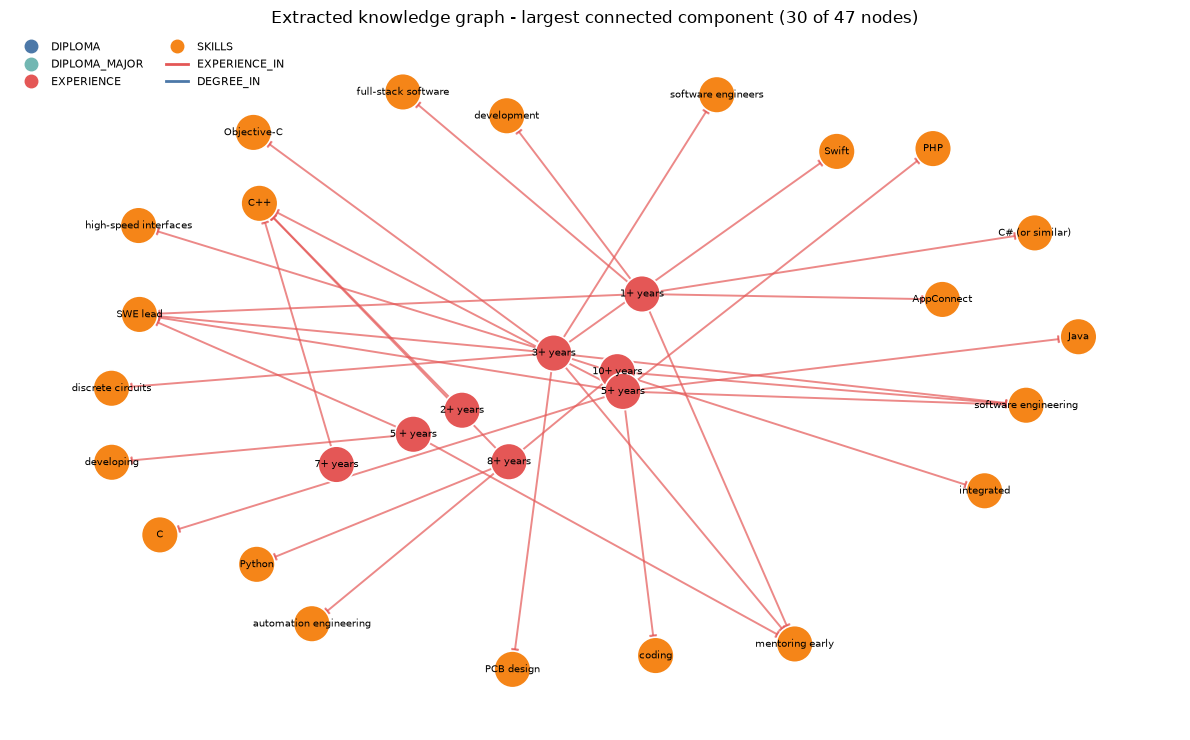

In [18]:
import networkx as nx
import matplotlib.pyplot as plt

# Build the graph over the whole test set, not just one document.
G = nx.DiGraph()
for g in rel_test:
    _, found = extract(g.text)
    for head, ht, lab, child, ct, score in found:
        G.add_node(head, kind=ht)
        G.add_node(child, kind=ct)
        G.add_edge(head, child, label=lab)

print(f"{G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

# Plot the largest connected component so the figure stays readable.
comp = max(nx.connected_components(G.to_undirected()), key=len)
H = G.subgraph(comp)

NODE_COLORS = {"DIPLOMA": "#4C78A8", "DIPLOMA_MAJOR": "#72B7B2",
               "EXPERIENCE": "#E45756", "SKILLS": "#F58518"}
EDGE_COLORS = {"EXPERIENCE_IN": "#E45756", "DEGREE_IN": "#4C78A8"}

# Edge labels are dropped deliberately: within one component they are nearly all the same
# relation, so printing them just piles overlapping text over the middle of the graph.
# Colour carries the relation instead, and the legend names it once.
node_colors = [NODE_COLORS.get(H.nodes[n].get("kind"), "#BAB0AC") for n in H]
edge_colors = [EDGE_COLORS.get(H.edges[e].get("label"), "#999") for e in H.edges]

fig, ax = plt.subplots(figsize=(12, 7.5))
pos = nx.spring_layout(H, seed=SEED, k=0.9)
nx.draw_networkx_edges(H, pos, edge_color=edge_colors, width=1.4, alpha=0.7,
                       arrowsize=11, ax=ax)
nx.draw_networkx_nodes(H, pos, node_color=node_colors, node_size=700,
                       edgecolors="white", linewidths=1.2, ax=ax)
nx.draw_networkx_labels(H, pos, font_size=7, ax=ax)

from matplotlib.lines import Line2D
legend = ([Line2D([], [], marker="o", linestyle="", markersize=9, color=c, label=k)
           for k, c in NODE_COLORS.items()]
          + [Line2D([], [], color=c, linewidth=2, label=k) for k, c in EDGE_COLORS.items()])
ax.legend(handles=legend, loc="upper left", fontsize=8, frameon=False, ncol=2)

ax.set_title(f"Extracted knowledge graph - largest connected component "
             f"({H.number_of_nodes()} of {G.number_of_nodes()} nodes)")
ax.axis("off")
fig.tight_layout()
fig.savefig(FIGURES / "knowledge_graph.png", dpi=150)
plt.show()

## 9. Limitations

- **The corpus is tiny.** 53 training documents, 20 test documents, 507 positive relations
  in total. Differences of a few points between the two systems in section 6 are within
  noise; only large gaps mean anything.
- **Heavy class imbalance.** Positives are 5-7% of candidate pairs, which is why scoring is
  micro-averaged over positives rather than accuracy over all pairs.
- **Sections 4-6 assume gold entities.** That is the standard way to isolate relation
  quality, but it flatters both systems relative to the full pipeline: section 8's chain
  inherits every entity error from section 7's NER, and a missed entity silently removes
  every relation that entity would have participated in.
- **The section 7 NER is a demonstration, not a result.** 53 documents and a small
  `tok2vec` model; it exists so the chain can run from raw text.
- **The rule baseline was tuned on dev**, one distance cutoff per label. That is a fair
  comparison, but a richer rule system (dependency paths, negation handling) would be a
  stronger baseline than the one built here.
- **Two entity schemas across the project.** This corpus uses `DIPLOMA`/`DIPLOMA_MAJOR`/
  `EXPERIENCE`/`SKILLS`; notebook 01's resumes use a different 10-label set. Merging them
  would need a mapping and re-annotation, which is future work rather than a quick fix.